In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


IMPORTS

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

LOAD DATASET


In [26]:
df = pd.read_csv('data.csv')
print("Shape:", df.shape)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


EXPLORATORY DATA ANALYSIS


In [6]:
# ── BASIC INSPECTION ─────────────────────────────────────────────────────────

print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['diagnosis'].value_counts())

print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [28]:
# Drop useless columns
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

# Encode target: M = 1 (Malignant), B = 0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nEncoded target sample:\n", y.value_counts())

Features shape: (569, 30)
Target shape: (569,)

Encoded target sample:
 diagnosis
0    357
1    212
Name: count, dtype: int64


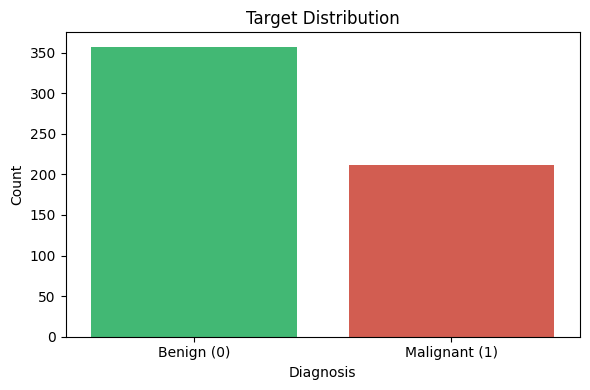

Benign: 357 (62.7%)
Malignant: 212 (37.3%)


In [8]:
# ── EDA: TARGET DISTRIBUTION ─────────────────────────────────────────────────

plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df, palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['Benign (0)', 'Malignant (1)'])
plt.title('Target Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Benign: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Malignant: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

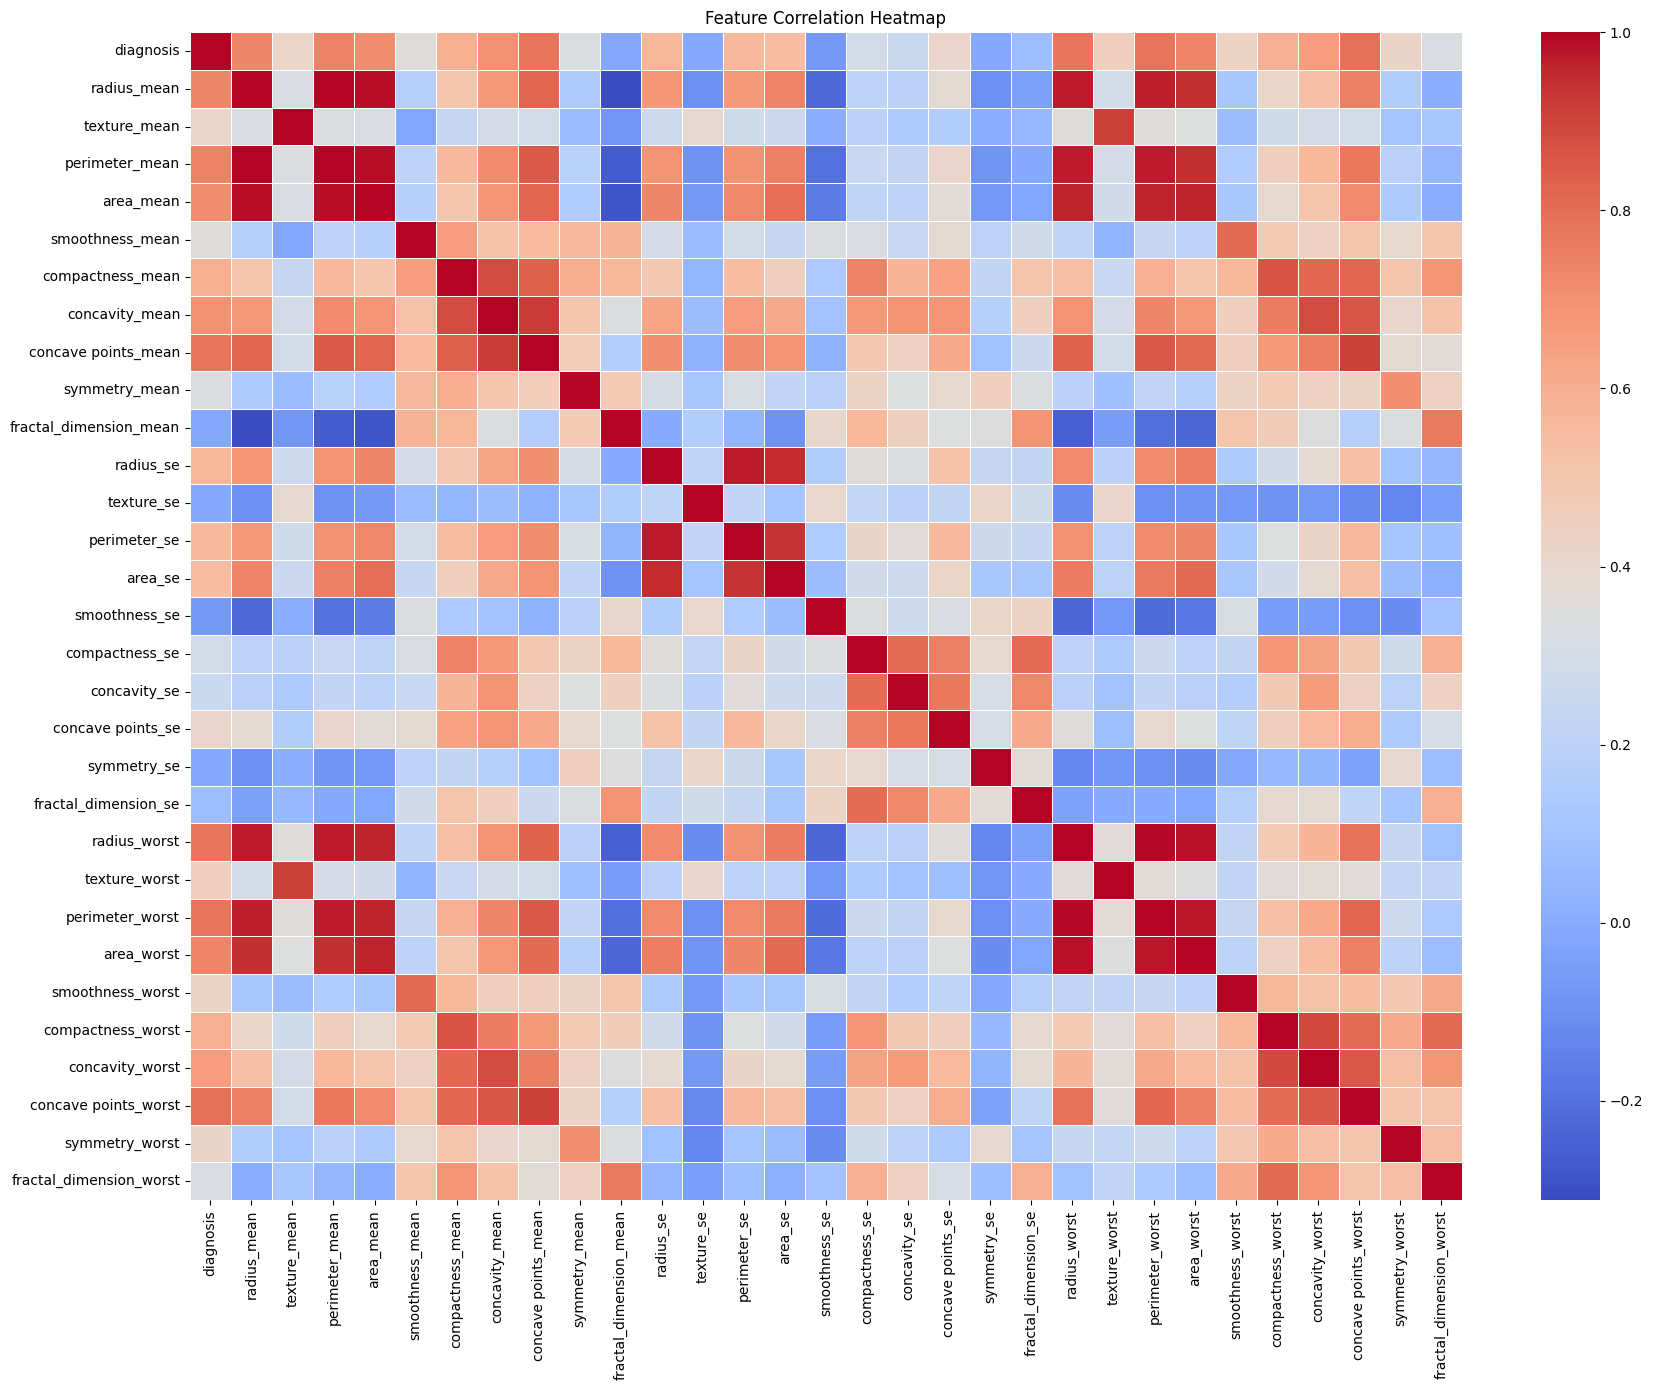

In [9]:
# ── EDA: CORRELATION HEATMAP ─────────────────────────────────────────────────

plt.figure(figsize=(18,14))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

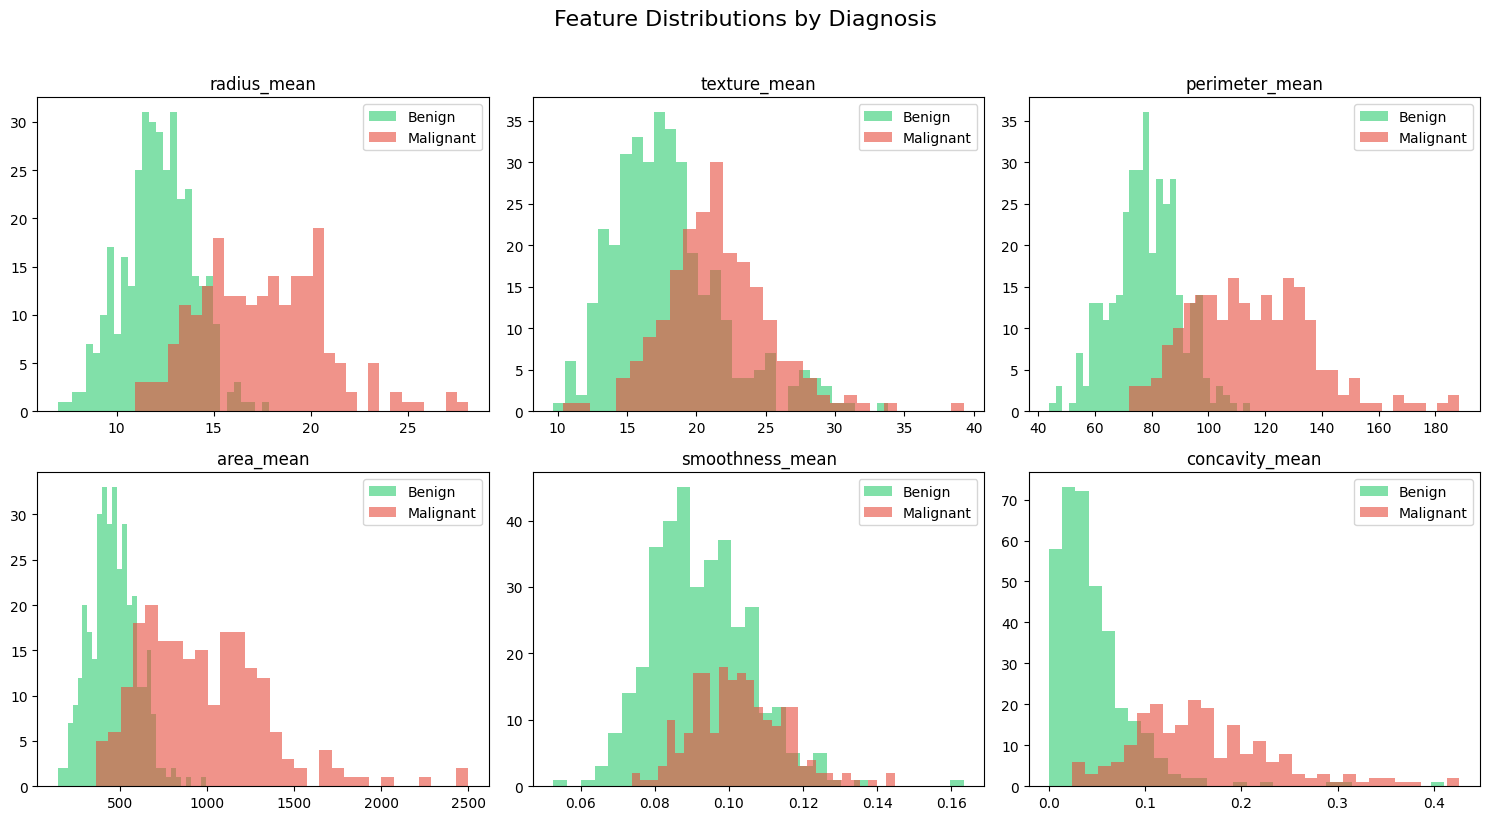

In [10]:
# ── EDA: FEATURE DISTRIBUTIONS ───────────────────────────────────────────────

mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'smoothness_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    axes[i].hist(df[df['diagnosis']==0][feature], alpha=0.6,
                 color='#2ecc71', label='Benign', bins=30)
    axes[i].hist(df[df['diagnosis']==1][feature], alpha=0.6,
                 color='#e74c3c', label='Malignant', bins=30)
    axes[i].set_title(feature)
    axes[i].legend()

plt.suptitle('Feature Distributions by Diagnosis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

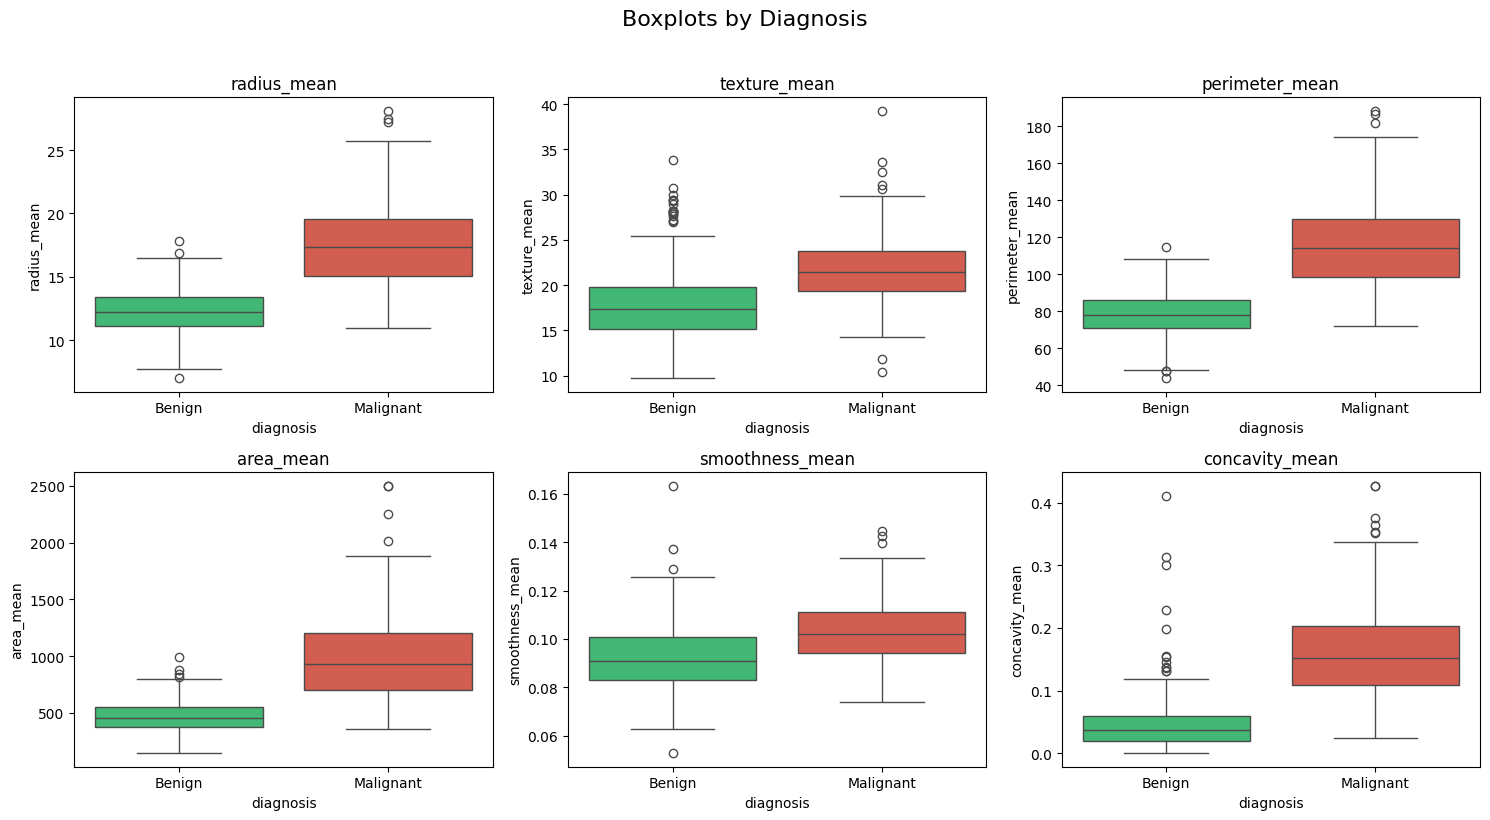

In [11]:
# ── EDA: BOXPLOTS ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    sns.boxplot(x='diagnosis', y=feature, data=df,
                palette=['#2ecc71','#e74c3c'], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xticklabels(['Benign', 'Malignant'])

plt.suptitle('Boxplots by Diagnosis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

DATA PREPROCESSING

In [12]:
# ── TRAIN TEST SPLIT ──────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: (455, 30)
Test set size: (114, 30)

Train target distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test target distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [13]:
# ── FEATURE SCALING ───────────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("Mean of first feature :", X_train_scaled[:,0].mean().round(4))
print("Std of first feature :", X_train_scaled[:,0].std().round(4))

Scaling done.
Mean of first feature : -0.0
Std of first feature : 1.0


MODEL BUILDING AND EVALUATION

In [14]:
# ── MODEL BUILDING ────────────────────────────────────────────────────────────

models = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'SVM'                 : SVC(probability=True, random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42),
    'XGBoost'             : XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Recall'    : classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        'Precision' : classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'F1'        : classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        'ROC-AUC'   : roc_auc_score(y_test, y_prob)
    }
    print(f"{name} done ✓")

print("\nAll models trained.")

Logistic Regression done ✓
KNN done ✓
SVM done ✓
Random Forest done ✓
XGBoost done ✓

All models trained.


In [15]:
# ── MODEL COMPARISON ──────────────────────────────────────────────────────────

results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df)

                     Accuracy  Recall  Precision      F1  ROC-AUC
Logistic Regression    0.9649  0.9286     0.9750  0.9512   0.9960
SVM                    0.9737  0.9286     1.0000  0.9630   0.9947
XGBoost                0.9737  0.9286     1.0000  0.9630   0.9940
Random Forest          0.9737  0.9286     1.0000  0.9630   0.9929
KNN                    0.9561  0.9048     0.9744  0.9383   0.9823


In [29]:
# ── CROSS VALIDATION ─────────────────────────────────────────────────────────

print("5-Fold Cross Validation Scores (Recall):\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='recall')
    print(f"{name:25s} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

5-Fold Cross Validation Scores (Recall):

Logistic Regression       Mean: 0.9471  Std: 0.0432
KNN                       Mean: 0.9176  Std: 0.0628
SVM                       Mean: 0.9529  Std: 0.0353
Random Forest             Mean: 0.9471  Std: 0.0432
XGBoost                   Mean: 0.9529  Std: 0.0300


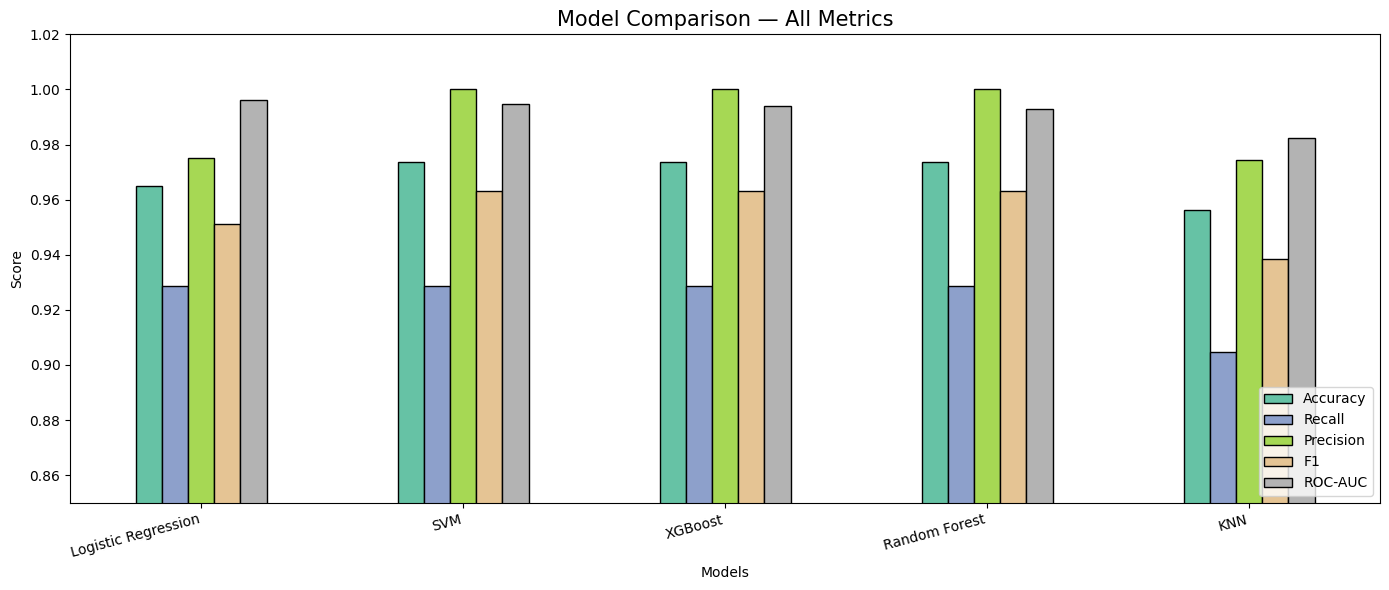

In [16]:
# ── VISUAL COMPARISON: METRICS BAR CHART ─────────────────────────────────────

results_df.plot(kind='bar', figsize=(14,6), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — All Metrics', fontsize=15)
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0.85, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

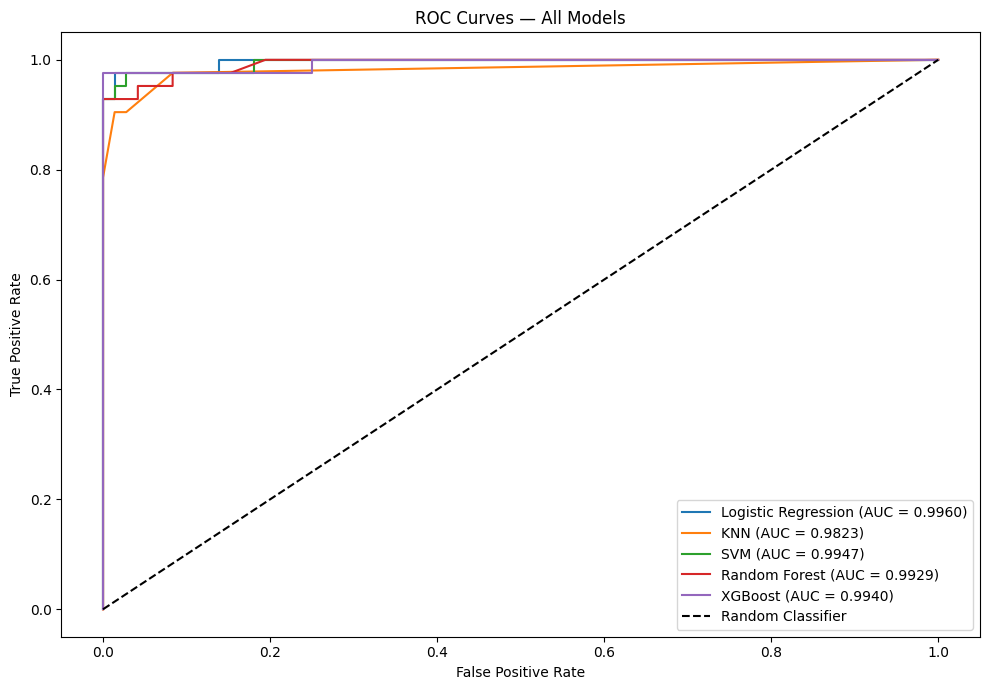

In [17]:
# ── VISUAL COMPARISON: ROC CURVES ────────────────────────────────────────────

plt.figure(figsize=(10,7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

MODEL TUNING

In [18]:
# ── HYPERPARAMETER TUNING: SVM ────────────────────────────────────────────────

param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'sigmoid'],
    'gamma'  : ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best Cross-Val Recall:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Val Recall: 0.9588


── Tuned SVM Results ──
Accuracy  : 0.9737
ROC-AUC   : 0.9927

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



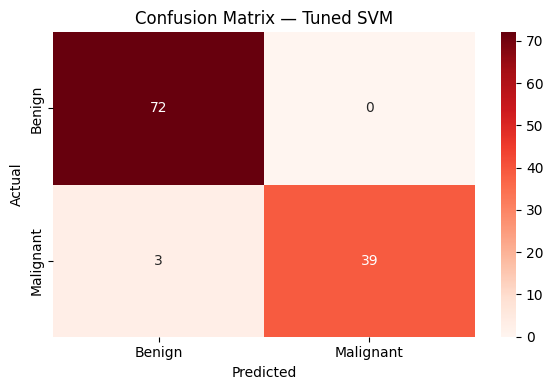

In [19]:
# ── TUNED SVM EVALUATION ──────────────────────────────────────────────────────

best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)
y_prob_tuned = best_svm.predict_proba(X_test_scaled)[:,1]

print("── Tuned SVM Results ──")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Benign','Malignant']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned),
            annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix — Tuned SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

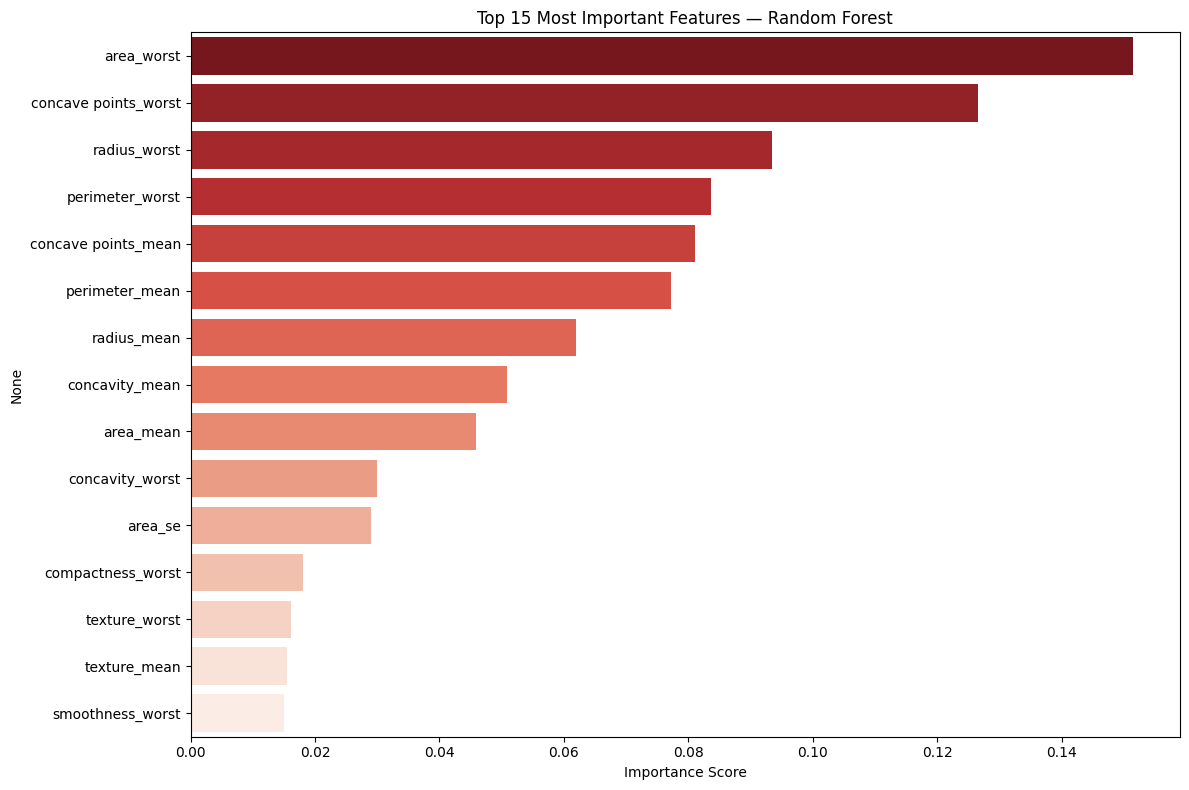


Top 10 Features:

area_worst              0.1514
concave points_worst    0.1265
radius_worst            0.0935
perimeter_worst         0.0836
concave points_mean     0.0811
perimeter_mean          0.0771
radius_mean             0.0620
concavity_mean          0.0508
area_mean               0.0459
concavity_worst         0.0300
dtype: float64


In [20]:
# ── FEATURE IMPORTANCE: RANDOM FOREST ────────────────────────────────────────

feat_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=feat_importance.values[:15],
            y=feat_importance.index[:15],
            palette='Reds_r')
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:\n")
print(feat_importance.head(10).round(4))

## Conclusion

### Objective
Binary classification of breast tumors as Malignant (1) or Benign (0) using 30 numerical
features extracted from digitized cell nucleus images.

### Dataset
- 569 samples, 30 features
- Mild class imbalance: 62.7% Benign, 37.3% Malignant
- No missing values, no duplicate rows
- Stratified train-test split (80/20) to preserve class ratio

### Model Performance Summary

| Model | Accuracy | Recall | Precision | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.9649 | 0.9286 | 0.9750 | 0.9512 | 0.9960 |
| SVM | 0.9737 | 0.9286 | 1.0000 | 0.9630 | 0.9947 |
| XGBoost | 0.9737 | 0.9286 | 1.0000 | 0.9630 | 0.9940 |
| Random Forest | 0.9737 | 0.9286 | 1.0000 | 0.9630 | 0.9929 |
| KNN | 0.9561 | 0.9048 | 0.9744 | 0.9383 | 0.9823 |

### Key Findings

**1. Best Overall Model — SVM**
- Tied best on Accuracy (97.37%), Precision (100%) and F1 (0.9630)
- 2nd best ROC-AUC (0.9947)
- Hyperparameter tuning via GridSearchCV confirmed default parameters
  were near optimal (C=10, kernel=rbf, gamma=scale)

**2. Recall is the Critical Metric Here**
- In medical diagnosis, false negatives (predicting Benign when actually Malignant)
  are dangerous as they delay treatment
- All top models achieved 92.86% Recall — 3 Malignant cases were missed
- These are likely borderline tumors that sit between Benign and Malignant characteristics

**3. Logistic Regression — Surprisingly Competitive**
- Despite being the simplest model, achieved the highest ROC-AUC (0.9960)
- Demonstrates that on clean, well-structured data, simpler models can
  produce superior probability estimates

**4. Feature Importance Insights**
- `_worst` features (area, concave points, radius) dominated predictions
- Malignant tumors are identified primarily by their most extreme outlier cells
- Size-related features (area, radius, perimeter) were most diagnostically significant
- Smoothness, symmetry and fractal dimension contributed least

**5. Tuning Findings**
- Cross-validated Recall of 0.9588 dropped slightly to 0.9286 on unseen test data
- This marginal drop indicates the model is not overfitting

### Limitations
- Small dataset (569 samples) — larger datasets may yield different feature importance
- 3 Malignant cases misclassified as Benign — dangerous in real clinical settings
- Model should not be used for actual medical diagnosis without clinical validation

### Tools & Libraries
Python, Pandas, NumPy, Scikit-learn, XGBoost, Matplotlib, Seaborn